# Deep RecSys Course
## Домашнее задание 3: Нейросетевое ранжирование
### ФИО: Швецов Олег Андреевич

В этом задании вы изучите способы кодирования вещественных и категориальных признаков, а затем обучите multi-task нейросетевую ранжирующую модель на основе DCN V2 со смесью экспертов.

Модель будет одновременно решать две задачи:
- предсказание полного прослушивания трека;
- предсказание лайка на трек.

Разбалловка

1. Подготовка датасета (1 балл)  
2. Обучение бейзлайнов и оценка качества (1 балл)  
3. Concat+MLP модель (3 балла)  
4. DCN-v2 (3 балла)  
5. Многоголовость (2 балла)  

# 1. Подготовка датасета (1 балл)

## yambda-50m-lag-features

Мы будем использовать датасет с уже заранее посчитанными признаками по Yambda.

Как был построен этот датасет:

1. За основу взят датасет Yambda `flat/50m multi_event`.
2. Из него были оставлены только неорганические события, то есть события, полученные с рекомендательных поверхностей, например из Моей Волны в Яндекс Музыке.
3. `is_skip = True`, если пользователь прослушал меньше половины трека.
4. `is_full_play = True`, если пользователь прослушал более 95% трека.
5. В Yambda лайк и прослушивание — это разные события. При этом модель обучается на событиях прослушивания: именно для них считаются признаки, и именно для них модель должна предсказывать таргеты. Поэтому лайки нужно атрибуцировать прослушиваниям, то есть понять, к какому именно прослушиванию относится каждый лайк. Для этого каждый лайк привязывается к ближайшему по времени прослушиванию того же `(uid, item_id)` в пределах 24 часов. Если подходящих прослушиваний два, выбирается ближайшее; при равенстве выбирается предыдущее. После этого `is_like = True` у прослушивания, если к нему был привязан хотя бы один лайк.
6. После этого по набору данных вычисляются вещественные счётчики. Они делятся на три типа: пользовательские, трековые и кросс-счётчики. Важно, что для каждого прослушивания с `timestamp` все счётчики считаются не в момент самого события, а в момент `timestamp - lag_seconds`, где `lag_seconds = 15 минут`. Такая задержка нужна, чтобы не допустить ликов при обучении и оценке. Идея в том, что при предсказании для текущего прослушивания модель не должна использовать информацию, которая появилась только после этого события или слишком близко к нему и в реальной системе ещё не успела бы попасть в признаки. Это особенно важно в нашей постановке, потому что далее качество будет оцениваться на соседних по времени прослушиваниях. Значит, при сравнении текущего трека с предыдущим нельзя допустить, чтобы признаки текущего объекта уже содержали фидбек на предыдущий трек, который к моменту предсказания ещё не должен был быть доступен. Иначе модель фактически будет подглядывать в ответ, а качество окажется завышенным. Кроме того, такой лаг лучше соответствует тому, как признаки обычно обновляются в реальных рекомендательных системах: не мгновенно, а с некоторой задержкой.
7. `is_like` и `is_full_play` используются как таргеты в задаче multi-task learning.

Код построения датасета можно посмотреть здесь: https://huggingface.co/datasets/matfu21/yambda-50m-lag-features/blob/main/event_processor.py#L296

In [2]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/olezha21212/tests-hw3')
import tests

In [92]:
import warnings
warnings.filterwarnings("ignore")

import gc
import polars as pl
import tests
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="matfu21/yambda-50m-lag-features",
    repo_type="dataset",
    filename="listens.parquet",
)
listens = pl.read_parquet(path)

## Оставляем только предпочтительные пары

В задачах ранжирования модель обычно обучается не на всех событиях подряд, а на специально отобранных объектах, которые несут сигнал о пользовательских предпочтениях. Это особенно важно для относительно небольших ранжирующих моделей. Если обучать такую модель на всех примерах подряд, она будет в большей степени учиться предсказывать глобальные вероятности лайка или полного прослушивания, чем правильно упорядочивать близкие по времени объекты. В результате качество именно на тех локальных попарных сравнениях, которые нас реально интересуют, может ухудшаться. Поэтому на практике датасеты для обучения ранжирования часто семплируются так, чтобы оставлять только примеры с полезным фидбеком.

При этом важно понимать, что это скорее инженерный компромисс, а не фундаментальное ограничение. Если бы у нас были очень большие модели с высокой выразительной способностью и без жёстких ограничений по вычислениям, то в идеале действительно хотелось бы учиться на всех доступных событиях. Такая модель могла бы одновременно хорошо восстанавливать глобальные закономерности и при этом качественно моделировать локальные предпочтения. Но в реальных рекомендательных системах ранжирующие модели обычно остаются относительно компактными, поэтому им полезно помогать фокусироваться именно на тех примерах, которые наиболее важны для ранжирования.

Почему ранжирующие модели обычно относительно небольшие: такие модели работают на финальном этапе ранжирования, где нужно очень быстро пересчитать score для большого числа кандидатов. У системы обычно есть жёсткие ограничения по latency, памяти и числу запросов в секунду. Поэтому слишком большие модели здесь использовать трудно: они будут слишком дорогими и медленными в продакшене. Именно из-за этого особенно важно, чтобы маленькая или средняя по размеру модель тратила свою выразительную способность на действительно полезные примеры, а не на предсказание усреднённых глобальных вероятностей.

В этом задании вам нужно оставить только те прослушивания, которые входят хотя бы в одну локальную пару с различающимся фидбеком. Идея такая: если у текущего трека и у соседнего по времени трека разный сигнал, то такая пара помогает обучать ранжирование. Если же и слева, и справа фидбек одинаковый, то текущее событие менее полезно для этой постановки.

### Что нужно сделать

Для каждого события нужно:
1. посмотреть на предыдущее событие того же пользователя;
2. посмотреть на следующее событие того же пользователя;
3. проверить, отличается ли `is_like` или `is_full_play` хотя бы с одной из сторон;
4. оставить только те строки, для которых такое отличие есть.

### Важная деталь про сортировку

Перед тем как смотреть на соседние события, данные нужно отсортировать по:
- `uid`,
- `timestamp`,
- `row_id`.

Поле `row_id` нужно для детерминированности. У одного и того же пользователя могут встретиться события с одинаковым `timestamp`, и тогда сортировка только по `uid` и `timestamp` не задаёт однозначный порядок. Добавление `row_id` делает этот порядок фиксированным и воспроизводимым.

In [93]:
def extract_preference_pairs(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .with_row_index("row_id")
        .sort(["uid", "timestamp", "row_id"])
        .with_columns([
            pl.col("is_like").shift(1).over("uid").alias("prev_is_like"),
            pl.col("is_full_play").shift(1).over("uid").alias("prev_is_full_play"),
            pl.col("is_like").shift(-1).over("uid").alias("next_is_like"),
            pl.col("is_full_play").shift(-1).over("uid").alias("next_is_full_play"),
        ])
        .filter(
            (pl.col("is_like") != pl.col("prev_is_like")) |
            (pl.col("is_like") != pl.col("next_is_like")) |
            (pl.col("is_full_play") != pl.col("prev_is_full_play")) |
            (pl.col("is_full_play") != pl.col("next_is_full_play"))
        )
        .drop([
            "row_id",
            "prev_is_like",
            "prev_is_full_play",
            "next_is_like",
            "next_is_full_play"
        ])
    )

listens = extract_preference_pairs(listens)
tests.test_extract_preference_pairs(listens)

All good! :)


## Набор данных Yambda

В этом задании мы будем использовать датасет Yambda: https://huggingface.co/datasets/yandex/yambda. Из него мы получим информацию об альбомах, к которым относится трек, а также об артистах этого трека. Эти данные понадобятся вам для построения мультивалентных признаков.

Ниже приведён класс из Hugging Face, который вам предстоит использовать.

In [94]:
from dataclasses import dataclass


@dataclass
class DatasetConfig:
    dataset_type: str = 'flat'
    dataset_size: str = '50m'
    interaction_name: str = 'multi_event'
    default_like_window_seconds: int = 24 * 60 * 60
    lag_seconds: int = 15 * 60

dataset_config = DatasetConfig()

In [95]:
from typing import Literal
from datasets import Dataset, DatasetDict, load_dataset


# YambdaDataset wrapper class (https://huggingface.co/datasets/yandex/yambda)
class YambdaDataset:
    INTERACTIONS = frozenset([
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ])

    def __init__(
        self,
        dataset_type: Literal["flat", "sequential"] = "flat",
        dataset_size: Literal["50m", "500m", "5b"] = "50m"
    ):
        assert dataset_type in {"flat", "sequential"}
        assert dataset_size in {"50m", "500m", "5b"}
        self.dataset_type = dataset_type
        self.dataset_size = dataset_size

    def interaction(self, event_type: Literal[
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ]) -> Dataset:
        assert event_type in YambdaDataset.INTERACTIONS
        return self._download(f"{self.dataset_type}/{self.dataset_size}", event_type)

    def audio_embeddings(self) -> Dataset:
        return self._download("", "embeddings")

    def album_item_mapping(self) -> Dataset:
        return self._download("", "album_item_mapping")

    def artist_item_mapping(self) -> Dataset:
        return self._download("", "artist_item_mapping")

    @staticmethod
    def _download(data_dir: str, file: str) -> Dataset:
        data = load_dataset("yandex/yambda", data_dir=data_dir, data_files=f"{file}.parquet")
        # Returns DatasetDict; extracting the only split
        assert isinstance(data, DatasetDict)
        return data["train"]


In [96]:
yambda_dataset = YambdaDataset(
    dataset_type=dataset_config.dataset_type,
    dataset_size=dataset_config.dataset_size
)
albums = yambda_dataset.album_item_mapping().to_polars()
artists = yambda_dataset.artist_item_mapping().to_polars()

## Добавляем мультивалентные признаки

Ранее мы загрузили данные `albums` и `artists`. Теперь на их основе нужно добавить в таблицу две новые колонки с мультивалентными категориальными признаками:
- `artist_ids` — список артистов, соответствующих данному треку;
- `album_ids` — список альбомов, соответствующих данному треку.

Таким образом, для каждого трека в этих колонках должен храниться не один идентификатор, а список идентификаторов.

In [97]:
def join_item_artist_album(
    listens: pl.DataFrame,
    artists: pl.DataFrame,
    albums: pl.DataFrame,
) -> pl.DataFrame:
    artist_mapping = (
        artists
        .group_by("item_id")
        .agg(pl.col("artist_id").alias("artist_ids"))
    )

    album_mapping = (
        albums
        .group_by("item_id")
        .agg(pl.col("album_id").alias("album_ids"))
    )

    return (
        listens
        .join(artist_mapping, on="item_id", how="left")
        .join(album_mapping, on="item_id", how="left")
        .with_columns([
            pl.col("artist_ids").fill_null(pl.lit([])),
            pl.col("album_ids").fill_null(pl.lit([])),
        ])
    )

listens = join_item_artist_album(listens, artists, albums)
tests.test_join_item_artist_album(listens)
del artists, albums
gc.collect()

All good! :)


18337

## Разбиваем данные на обучающую и тестовую выборки

Далее вам нужно написать функцию, которая делит датасет на две части по времени:
- в `train` попадают все события, кроме последних `test_last_seconds` секунд;
- в `test` попадают события из последних `test_last_seconds` секунд, включая границу.

В этом задании в качестве тестовой выборки мы будем использовать последние 30 дней.

In [98]:
def temporal_train_test_split(
    df: pl.DataFrame,
    test_last_seconds: float,
    time_column: str = "timestamp",
) -> tuple[pl.DataFrame, pl.DataFrame]:
    max_ts = df.select(pl.col(time_column).max()).item()
    th = max_ts - test_last_seconds
    train = df.filter(pl.col(time_column) < th)
    test = df.filter(pl.col(time_column) >= th)
    return train, test

train_listens, test_listens = temporal_train_test_split(listens, test_last_seconds=30 * 24 * 60 * 60)
tests.test_temporal_train_test_split(train_listens, test_listens)
del listens
gc.collect()

All good! :)


0

# 2. Обучение бейзлайнов и оценка качества (1 балл)

## Pairwise accuracy

Метрика, которой будет оцениваться качество вашего решения, называется `pairwise accuracy`.

Идея метрики такая: мы хотим проверить, умеет ли модель правильно упорядочивать соседние по времени события одного пользователя. Например, если в паре соседних треков на один был лайк, а на другой нет, то трек с лайком должен получить больший скор.

Функция получает на вход:
- `uids` — идентификаторы пользователей;
- `timestamps` — времена событий;
- `labels` — бинарные таргеты (`0` или `1`);
- `probs` — предсказанные моделью скоры;
- `session_gap_seconds` — максимальный допустимый разрыв по времени между соседними событиями.

Что нужно реализовать:
1. сгруппировать события по пользователям;
2. внутри каждого пользователя отсортировать события по времени;
3. рассмотреть только соседние пары;
4. отбросить пары, у которых разница по времени больше `session_gap_seconds`;
5. оставить только пары, у которых различаются `label`;
6. проверить, совпадает ли порядок по `probs` с порядком по `label`.

Вклад одной пары:
- 1, если модель ранжирует пару правильно;
- 0, если неправильно;
- 0.5, если скоры равны.

Формально, для соседней валидной пары $(i, i+1)$:

$$
m(i, i+1)=
\begin{cases}
1, & \text{если } (y_{i+1}-y_i)(s_{i+1}-s_i) > 0, \\
0.5, & \text{если } s_{i+1} = s_i, \\
0, & \text{иначе.}
\end{cases}
$$

Итоговая метрика:

$$
\text{PairwiseAccuracy} =
\frac{1}{|P|}\sum_{(i,i+1)\in P} m(i,i+1),
$$

где $P$ — множество всех валидных соседних пар по всем пользователям.

Почему мы смотрим именно на соседние пары: в рекомендательных задачах контекст пользователя быстро меняется. Если сравнивать два события, между которыми прошло много времени, такое сравнение уже может быть некорректным: пользователь был в другом состоянии, слушал другую музыку и вообще решал другую задачу. Поэтому мы сравниваем только локальные, соседние по времени события.

По этой же причине здесь не очень подходит ROC AUC. Эта метрика фактически сравнивает позитивные и негативные объекты между собой глобально, в том числе из совершенно разных моментов времени. В результате модель может получить хороший ROC AUC, даже если она плохо упорядочивает близкие по времени события внутри реальной пользовательской последовательности. `Pairwise accuracy` лучше отражает именно качество локального ранжирования, которое важно в этой задаче.

Дополнительно важно, что временной порог в метрике согласован с лагом, который использовался при построении признаков. В признаках мы используем задержку 15 минут, чтобы модель не могла опираться на слишком свежий фидбек, который в реальной системе ещё не успел бы попасть в фичи. В метрике используется тот же порог: если два соседних события находятся друг от друга дальше, чем на 15 минут, мы их не сравниваем. Это делает постановку более согласованной: и при построении признаков, и при оценке качества мы работаем в одном и том же локальном временном окне.

## Считаем метрики случайного бейзлайна

Перед обучением модели полезно посчитать качество простого случайного бейзлайна. Для этого сгенерируйте для каждого объекта в тестовой выборке случайный скор и посчитайте по нему обе метрики `pairwise accuracy`:
- по таргету `is_like`;
- по таргету `is_full_play`.

На этом шаге нужно:
1. взять тестовую выборку;
2. сгенерировать для каждого объекта случайное значение score;
3. вычислить `pair_accuracy_like`;
4. вычислить `pair_accuracy_full_play`.

В результате у вас должен получиться словарь `metrics` с двумя значениями метрик для случайного ранжирования.

In [99]:
import numpy as np

def compute_pairwise_accuracy(
    uids: np.ndarray,
    timestamps: np.ndarray,
    labels: np.ndarray,
    probs: np.ndarray,
    session_gap_seconds: int = 15 * 60,
) -> float:
    unique_uids, group_indices = np.unique(uids, return_inverse=True)

    total_score = 0.0
    total_pairs = 0

    for uid_idx in range(len(unique_uids)):
        mask = group_indices == uid_idx
        if np.sum(mask) < 2:
            continue

        user_ts = timestamps[mask]
        user_labels = labels[mask]
        user_probs = probs[mask]

        sort_idx = np.argsort(user_ts)
        user_ts = user_ts[sort_idx]
        user_labels = user_labels[sort_idx]
        user_probs = user_probs[sort_idx]

        for i in range(len(user_ts) - 1):
            if user_ts[i + 1] - user_ts[i] > session_gap_seconds:
                continue
            if user_labels[i] == user_labels[i + 1]:
                continue

            diff_label = user_labels[i + 1] - user_labels[i]
            diff_score = user_probs[i + 1] - user_probs[i]

            if diff_score == 0.0:
                contrib = 0.5
            elif np.sign(diff_label) == np.sign(diff_score):
                contrib = 1.0
            else:
                contrib = 0.0

            total_score += contrib
            total_pairs += 1

    return total_score / total_pairs

tests.test_pairwise_accuracy(compute_pairwise_accuracy)

All good! :)


In [100]:
np.random.seed(42)

random_scores = np.random.rand(len(test_listens))

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_like"].to_numpy().astype(np.int32),
        probs=random_scores
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_full_play"].to_numpy().astype(np.int32),
        probs=random_scores
    )
}
tests.test_random_baseline_metrics(metrics)

All good! :)


In [101]:
metrics

{'pair_accuracy_like': 0.5034397305006647,
 'pair_accuracy_full_play': 0.49954200603606785}

## Считаем метрики popularity baseline

Ещё один простой бейзлайн — ранжировать треки по их популярности в обучающей выборке. Для этого посчитайте, сколько раз каждый `item_id` встретился в `train`, и используйте это значение как score на `test`.

На этом шаге нужно:
1. по обучающей выборке посчитать популярность каждого трека (сколько раз он встретился);
2. присоединить эту популярность к объектам тестовой выборки;
3. для треков, которых не было в `train`, подставить `0`;
4. вычислить `pair_accuracy_like`;
5. вычислить `pair_accuracy_full_play`.

В результате у вас должен получиться словарь `metrics` с двумя значениями метрик для popularity baseline.

In [102]:
popularity = (
    train_listens
    .filter(pl.col("is_full_play") == True)
    .group_by("item_id")
    .agg(pl.col("item_id").count().alias("pop_score"))
)

test_with_pop = test_listens.join(
    popularity, 
    on="item_id", 
    how="left"
).with_columns(
    pl.col("pop_score").fill_null(0.0)
)

pop_scores = test_with_pop["pop_score"].to_numpy()

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_with_pop["uid"].to_numpy(),
        timestamps=test_with_pop["timestamp"].to_numpy(),
        labels=test_with_pop["is_like"].to_numpy().astype(np.int32),
        probs=pop_scores
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_with_pop["uid"].to_numpy(),
        timestamps=test_with_pop["timestamp"].to_numpy(),
        labels=test_with_pop["is_full_play"].to_numpy().astype(np.int32),
        probs=pop_scores
    )
}

tests.test_popularity_baseline_metrics(metrics)

All good! :)


In [103]:
metrics

{'pair_accuracy_like': 0.48602811156859455,
 'pair_accuracy_full_play': 0.5295152915969923}

## Обучаем CatBoost baseline

Теперь обучим ещё один бейзлайн — модель CatBoost. В отличие от предыдущих простых бейзлайнов, здесь модель уже будет использовать признаки из датасета и учиться предсказывать таргет по обучающей выборке.

На этом шаге нужно:
1. взять вещественные признаки `DENSE_COLUMNS` и категориальные признаки `SPARSE_COLUMNS`;
2. обучить `CatBoostClassifier` на задаче предсказания `is_full_play`;
3. получить предсказанные вероятности на тестовой выборке;
4. использовать вероятность полного прослушивания как score;
5. посчитать `pair_accuracy_like`;
6. посчитать `pair_accuracy_full_play`.

Обратите внимание, что модель обучается только на таргете `is_full_play`, но качество нужно измерить по обоим таргетам. Это позволит понять, насколько предсказание лайка переносится на задачу ранжирования по полному прослушиванию.

В результате у вас должен получиться словарь `metrics` с двумя значениями:
- `pair_accuracy_like`;
- `pair_accuracy_full_play`.

In [104]:
DENSE_COLUMNS: tuple[str, ...] = (
    "user_lag_listen_cnt",
    "user_lag_like_cnt",
    "user_lag_full_play_cnt",
    "user_lag_skip_cnt",
    "item_lag_listen_cnt",
    "item_lag_like_cnt",
    "item_lag_full_play_cnt",
    "item_lag_skip_cnt",
    "ui_lag_listen_cnt",
    "ui_lag_like_cnt",
    "ui_lag_full_play_cnt",
    "ui_lag_skip_cnt",
    "user_lag_avg_played_ratio",
    "item_lag_avg_played_ratio",
    "ui_lag_avg_played_ratio",
)
MULTIVALENT_COLUMNS: tuple[str, ...] = ("artist_ids", "album_ids")
SPARSE_COLUMNS = ("uid", "item_id")
LABEL_COLUMNS = ("is_like", "is_full_play")

In [105]:
from catboost import CatBoostClassifier, Pool
import numpy as np

X_train = train_listens.select(list(DENSE_COLUMNS) + list(SPARSE_COLUMNS))
y_train = train_listens["is_full_play"].to_numpy().astype(int)

X_test = test_listens.select(list(DENSE_COLUMNS) + list(SPARSE_COLUMNS))
cat_features = list(SPARSE_COLUMNS)

In [106]:
train_pool = Pool(
    data=X_train.to_pandas(),
    label=y_train,
    cat_features=cat_features
)
test_pool = Pool(
    data=X_test.to_pandas(), 
    cat_features=cat_features
)

In [107]:
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=8,
    loss_function='Logloss',
    verbose=10,
    random_seed=42,
    task_type="GPU",
)

model.fit(train_pool)

0:	learn: 0.6893433	total: 75.3ms	remaining: 7.45s
10:	learn: 0.6728438	total: 680ms	remaining: 5.5s
20:	learn: 0.6683913	total: 1.22s	remaining: 4.58s
30:	learn: 0.6668031	total: 1.76s	remaining: 3.92s
40:	learn: 0.6659892	total: 2.29s	remaining: 3.3s
50:	learn: 0.6655414	total: 2.79s	remaining: 2.68s
60:	learn: 0.6651412	total: 3.31s	remaining: 2.12s
70:	learn: 0.6648693	total: 3.82s	remaining: 1.56s
80:	learn: 0.6646397	total: 4.32s	remaining: 1.01s
90:	learn: 0.6644313	total: 4.83s	remaining: 478ms
99:	learn: 0.6642763	total: 5.3s	remaining: 0us


CatBoostClassifier(depth=8, iterations=100, learning_rate=0.1, loss_function='Logloss', random_seed=42, task_type='GPU', verbose=10)

In [108]:
catboost_probs = model.predict_proba(test_pool)[:, 1]

In [109]:
metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_like"].to_numpy().astype(np.float32),
        probs=catboost_probs
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=test_listens["uid"].to_numpy(),
        timestamps=test_listens["timestamp"].to_numpy(),
        labels=test_listens["is_full_play"].to_numpy().astype(np.float32),
        probs=catboost_probs
    )
}

tests.test_catboost_baseline_metrics(metrics)

All good! :)


In [110]:
metrics

{'pair_accuracy_like': 0.4871768395781974,
 'pair_accuracy_full_play': 0.5915695351867648}

# 3. Concat+MLP модель (3 балла)

В этом задании вам предстоит реализовать первое нейросетевое решение.

Идея модели очень простая:
1. вещественные признаки кодируются с помощью `PiecewiseLinearEncoder`;
2. категориальные и мультивалентные признаки кодируются с помощью `Multisize Unified Embeddings`;
3. все полученные представления конкатенируются в один вектор;
4. этот вектор подаётся в простую полносвязную сеть с `ReLU` в качестве нелинейности.

На этом этапе модель предсказывает только вероятность полного прослушивания, то есть решается одна бинарная задача. Пока что речь о multi-task learning и нескольких головах не идёт.

Таким образом, вам нужно реализовать модель, которая:
- получает dense-, sparse- и multivalent-признаки;
- кодирует каждый тип признаков своим энкодером;
- объединяет все представления;
- пропускает результат через `MLP`;
- выдаёт скалярный score для предсказания полного прослушивания.

## Готовим датасет для обучения

Теперь нужно реализовать класс `RankerDataset`, который будет подготавливать батчи для обучения нейросетевой модели.

В этом задании батчевание происходит **на этапе самого датасета**, а не в `DataLoader`. Здесь это сделано специально: табличные данные уже лежат целиком в памяти, а модель сама по себе небольшая, поэтому узким местом легко становится именно подготовка батчей и перекладывание данных. Если формировать большие батчи на лету, то даже при больших `num_workers` и `prefetch_factor` загрузка данных может стать bottleneck. Поэтому здесь удобнее заранее нарезать датафрейм на батчи и хранить их в готовом виде внутри датасета.

Вам дан каркас класса `RankerDataset`. Нужно реализовать его так, чтобы в конструкторе датафрейм разбивался на батчи размера `batch_size`, а каждый батч преобразовывался в словарь фиксированной структуры.

### Что нужно сделать

1. Проверить, что `batch_size >= 1`.
2. Разбить входной `df` на последовательные батчи размера `batch_size`.
3. Для каждого батча собрать dense-, sparse- и multivalent-признаки, а также таргеты и мета-информацию.
4. Последовательно применить к каждому батчу все функции из `transforms`.
5. Сохранить готовые батчи внутри датасета.
6. Реализовать:
   - `__len__` — количество батчей;
   - `__getitem__` — получение батча по индексу.

### Формат батча

Каждый батч должен быть словарём со следующими ключами:
- `labels`
- `dense_features`
- `sparse_features`
- `multivalent_features`
- `meta`

#### `labels`

Словарь, где ключами являются названия таргетов из `label_columns`, а значениями — одномерные `torch.Tensor` длины `batch_size`.

Пример:

```python
{
    "is_like": ...,
    "is_full_play": ...,
}
```

#### `dense_features`
Тензор размера [batch_size, num_dense_features] типа torch.float32.

#### `sparse_features`
Словарь, где для каждого имени из sparse_columns хранится одномерный тензор длины batch_size.

Пример:

```python
{
    "uid": ...,
    "item_id": ...,
}
```

#### `multivalent_features`
Словарь, где для каждого мультивалентного признака нужно сохранить ещё один словарь с двумя полями:
-  values — один общий плоский тензор со всеми значениями из списков;
- lengths — тензор длин списков для каждого объекта в батче.

Пример:

```python
{
    "artist_ids": {
        "values": ...,
        "lengths": ...,
    },
    "album_ids": {
        "values": ...,
        "lengths": ...,
    },
}
```

Именно в таком формате мультивалентные признаки удобно потом агрегировать внутри модели.

#### `meta`
Словарь с технической информацией о батче:

```python
{
    "timestamp": ...,
    "uid": ...,
    "item_id": ...,
}
```

Что такое transforms

Аргумент transforms — это список функций, которые принимают батч и возвращают преобразованный батч. Эти преобразования нужно применять последовательно к каждому уже собранному батчу.

То есть логика такая:
1. вы собрали батч в нужном формате;
2.	прогнали его через все функции из transforms;
3.	сохранили итоговый батч в датасет.

Это позволит дальше независимо добавлять, например, перенос на устройство, нормализацию, переименование полей или любые другие постобработки.

Дополнительные замечания
- Dense-признаки и таргеты нужно привести к torch.float32.
- Для мультивалентных признаков lengths и values должны быть целочисленными тензорами.
- Последний батч может быть неполным.
- Пустые батчи сохранять не нужно.

В результате ваш RankerDataset должен возвращать готовые батчи, а не отдельные объекты.

In [21]:
import polars as pl
from typing import Any, Callable
import torch
from torch.utils.data import Dataset


class RankerDataset(Dataset):
    def __init__(
        self,
        df: pl.DataFrame,
        transforms: list[Callable[[Any], Any]],
        label_columns: list[str],
        dense_columns: list[str],
        sparse_columns: list[str],
        multivalent_columns: list[str],
        batch_size: int,
    ):
        assert batch_size >= 1, "batch_size must be >= 1"
        
        self.batch_size = batch_size
        self.transforms = transforms
        
        self.label_columns = label_columns
        self.dense_columns = dense_columns
        self.sparse_columns = sparse_columns
        self.multivalent_columns = multivalent_columns
        
        n_rows = len(df)
        self.batches = []
        
        for start in range(0, n_rows, batch_size):
            end = min(start + batch_size, n_rows)
            batch_df = df.slice(start, end - start)
            
            if len(batch_df) == 0:
                continue
            batch = self._create_batch(batch_df)
            
            for transform in self.transforms:
                batch = transform(batch)
            
            self.batches.append(batch)
    
    def _create_batch(self, batch_df: pl.DataFrame) -> dict[str, Any]:
        batch = {}
        
        labels = {}
        for col in self.label_columns:
            labels[col] = torch.tensor(
                batch_df[col].to_numpy(), 
                dtype=torch.float32
            )
        batch["labels"] = labels
        
        if self.dense_columns:
            dense_values = batch_df.select(self.dense_columns).to_numpy()
            batch["dense_features"] = torch.tensor(dense_values, dtype=torch.float32)
        else:
            batch["dense_features"] = torch.empty((len(batch_df), 0), dtype=torch.float32)
        
        sparse = {}
        for col in self.sparse_columns:
            sparse[col] = torch.tensor(
                batch_df[col].to_numpy(), 
                dtype=torch.long
            )
        batch["sparse_features"] = sparse
        
        multivalent = {}
        for col in self.multivalent_columns:
            lists = batch_df[col].to_list()
            lengths = [len(lst) for lst in lists]
            
            values = []
            for lst in lists:
                values.extend(lst)
            
            multivalent[col] = {
                "values": torch.tensor(values, dtype=torch.long) if values else torch.empty(0, dtype=torch.long),
                "lengths": torch.tensor(lengths, dtype=torch.long),
            }
            
        batch["multivalent_features"] = multivalent
        
        batch["meta"] = {
            "timestamp": torch.tensor(batch_df["timestamp"].to_numpy(), dtype=torch.long),
            "uid": torch.tensor(batch_df["uid"].to_numpy(), dtype=torch.long),
            "item_id": torch.tensor(batch_df["item_id"].to_numpy(), dtype=torch.long),
        }
        
        return batch

    def __len__(self) -> int:
        return len(self.batches)
    
    def __getitem__(self, idx: int) -> dict[str, Any]:
        return self.batches[idx]

tests.test_ranker_dataset(RankerDataset)

All good! :)


## Multihash transform

Теперь реализуем `MultihashTransform` — преобразование, которое будет переводить sparse- и multivalent-признаки в набор хешей. Этот шаг нужен для дальнейшей работы с unified embeddings.

Идея здесь следующая: вместо того, чтобы хранить отдельную embedding-таблицу под каждый признак или использовать один-единственный хеш, мы отображаем каждый идентификатор сразу в несколько хешей с разными seed. В результате один и тот же исходный ID превращается в небольшой набор индексов. Такой подход предлагается в статье [Unified Embedding: Battle-Tested Feature Representations for Web-Scale ML Systems](https://arxiv.org/pdf/2305.12102) и позволяет компактнее работать с большим количеством категориальных признаков.

Вам дан каркас класса `MultihashTransform`. Нужно реализовать его так, чтобы он применял multihash-преобразование:
- к sparse-признакам;
- к multivalent-признакам.

### Что приходит на вход

На вход `__call__` подаётся `sample` — словарь батча, в котором уже есть поля:
- `sparse_features`;
- `multivalent_features`.

Именно их и нужно преобразовать.

### Что задаётся в конструкторе

- `sparse_features_config` — словарь вида  
  `{feature_name: [seed1, seed2, ...]}`  
  для sparse-признаков;
- `sparse_features_name` — имя поля в `sample`, где лежат sparse-признаки;
- `multivalent_features_config` — словарь такого же вида для multivalent-признаков;
- `multivalent_features_name` — имя поля в `sample`, где лежат multivalent-признаки;
- `cardinality` — размер общего хеш-пространства, то есть все индексы после хеширования должны лежать в диапазоне `[0, cardinality)`.

### Что нужно сделать

Для каждого sparse-признака:
1. взять тензор идентификаторов;
2. для каждого `seed` из конфига отдельно посчитать хеш;
3. привести хеш в диапазон `[0, cardinality)` с помощью взятия остатка;
4. сохранить результат обратно в `sample`.

Для каждого multivalent-признака:
1. взять плоский тензор `values`;
2. для каждого `seed` из конфига отдельно посчитать хеш;
3. привести хеш в диапазон `[0, cardinality)`;
4. сохранить результат обратно в `sample`, не меняя `lengths`.

### Какой формат должен получиться

Если исходный sparse-признак имел форму

```python
[batch_size]
```

то после multihash-преобразования он должен иметь форму

```python
[batch_size, num_hashes]
```

где num_hashes — число seed для этого признака.

Если values у multivalent-признака имели форму

```python
[num_values]
```

то после преобразования должно получиться

```python
[num_values, num_hashes]
```

Поле lengths у multivalent-признаков менять не нужно.

Важные замечания
- Для хеширования нужно использовать mmh3.
- Один и тот же исходный ID при одном и том же seed всегда должен давать один и тот же индекс.
- Разные seed должны давать разные хеш-проекции одного и того же ID.
- Все полученные индексы должны быть целыми числами из диапазона `[0, cardinality)`.
- Преобразование должно происходить in-place: нужно модифицировать sample и вернуть его обратно.

Итоговая идея такая: после MultihashTransform каждый категориальный ID заменяется не одним индексом, а набором индексов, полученных несколькими независимыми хеш-функциями.


In [22]:
from typing import Any
import mmh3


class MultihashTransform:
    def __init__(
        self,
        sparse_features_config: dict,
        sparse_features_name: str,
        multivalent_features_config: dict,
        multivalent_features_name: str,
        cardinality: int,
    ):
        self.sparse_features_config = sparse_features_config
        self.sparse_features_name = sparse_features_name
        self.multivalent_features_config = multivalent_features_config
        self.multivalent_features_name = multivalent_features_name
        self.cardinality = cardinality

    def __call__(self, sample: dict[str, Any]) -> dict[str, Any]:
        sparse_dict = sample[self.sparse_features_name]
        
        for feature_name, seeds in self.sparse_features_config.items():                
            tensor = sparse_dict[feature_name]
            hashes = []
            
            for seed in seeds:
                hashed = torch.tensor(
                    [mmh3.hash(str(x.item()), seed=seed) for x in tensor],
                    dtype=torch.long
                )
                hashed = hashed % self.cardinality
                hashed = hashed % self.cardinality
                hashes.append(hashed)
            
            sparse_dict[feature_name] = torch.stack(hashes, dim=1)

        multi_dict = sample[self.multivalent_features_name]
        
        for feature_name, seeds in self.multivalent_features_config.items():                
            values = multi_dict[feature_name]["values"]
            lengths = multi_dict[feature_name]["lengths"]
            
            hashes = []
            for seed in seeds:
                hashed = torch.tensor(
                    [mmh3.hash(str(x.item()), seed=seed) for x in values],
                    dtype=torch.long
                )
                hashed = hashed % self.cardinality
                hashed = hashed % self.cardinality
                hashes.append(hashed)
            
            multi_dict[feature_name]["values"] = torch.stack(hashes, dim=1)

        return sample

tests.test_multihash_transform(MultihashTransform)

All good! :)


## CategoricalEncoder

Теперь реализуем `CategoricalEncoder` — простой энкодер категориальных признаков. Его задача состоит в том, чтобы по входным индексам возвращать соответствующие embedding-векторы.

В конструктор класса передаётся объект `nn.Embedding`, который нужно сохранить внутри модуля. В методе `forward` на вход подаётся тензор `ids`, а на выходе должен получаться результат применения `embeddings(ids)`.

Иными словами, `CategoricalEncoder` — это тонкая обёртка над `nn.Embedding`.

### Что нужно реализовать

1. Сохранить переданный слой `embeddings`.
2. В `forward` применить его к тензору `ids`.
3. Вернуть получившийся тензор.

### Ожидаемое поведение

Если на вход подан тензор индексов формы

```python
[batch_size]
```

то на выходе должен получиться тензор формы

```python
[batch_size, embedding_dim]
```

Если на вход подан тензор формы

```python
[batch_size, num_hashes]
```

то на выходе должен получиться тензор формы

```python
[batch_size, num_hashes, embedding_dim]
```

То есть энкодер должен работать с произвольной входной формой так же, как обычный nn.Embedding.


In [23]:
import torch
import torch.nn as nn


class CategoricalEncoder(nn.Module):
    def __init__(self, embeddings: nn.Embedding):
        super().__init__()
        self.embeddings = embeddings

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        return self.embeddings(ids)
        
tests.test_categorical_encoder(CategoricalEncoder)

All good! :)


## MultivalentEncoder

Теперь реализуем `MultivalentEncoder` — энкодер для мультивалентных категориальных признаков. В отличие от обычного категориального признака, здесь каждому объекту соответствует не один ID, а список ID, например список артистов или альбомов.

В конструктор класса передаётся объект `nn.Embedding`, который нужно сохранить внутри модуля. В методе `forward` на вход подаются:
- `ids` — плоский тензор идентификаторов после `MultihashTransform`;
- `lengths` — длины списков для каждого объекта в батче.

Нужно получить embedding для каждого ID, а затем усреднить эмбеддинги внутри каждого списка. Для этого удобно использовать `torch.nn.functional.embedding_bag` с режимом `"mean"`.

### Что нужно реализовать

1. Сохранить переданный слой `embeddings`.
2. В `forward` агрегировать эмбеддинги по спискам с помощью среднего.
3. Вернуть тензор представлений объектов.

### Ожидаемое поведение

Если на вход подан:
- `ids` формы `[num_values, num_hashes]`,
- `lengths` формы `[batch_size]`,

то на выходе должен получиться тензор формы

```python
[batch_size, num_hashes, embedding_dim]
```

То есть для каждого объекта в батче нужно получить по одному усреднённому embedding-представлению для каждого хеша.

In [24]:
from torch.nn.functional import embedding_bag


class MultivalentEncoder(nn.Module):
    def __init__(self, embeddings: nn.Embedding):
        super().__init__()
        self.embeddings = embeddings

    def forward(self, ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        batch_size = lengths.shape[0]
        num_hashes = ids.shape[1]

        offsets = torch.zeros(batch_size, dtype=torch.long, device=ids.device)
        offsets[1:] = lengths.cumsum(dim=0)[:-1]

        outputs = []
        for h in range(num_hashes):
            current_ids = ids[:, h] # [num_values]

            emb = embedding_bag(
                self.embeddings.weight, 
                current_ids, 
                offsets=offsets,
                mode='mean',
                sparse=False
            ) # [bs, embedding_dim]

            outputs.append(emb)

        # [bs, num_hashes, embedding_dim]
        return torch.stack(outputs, dim=1)

tests.test_multivalent_encoder(MultivalentEncoder)

All good! :)


## PiecewiseLinearEncoder

Теперь нужно реализовать `PiecewiseLinearEncoder` — слой для кусочно-линейного кодирования вещественных признаков как в статье [On Embeddings for Numerical Features in Tabular Deep Learning](https://arxiv.org/abs/2203.05556).

Идея этого преобразования такая: каждый вещественный признак разбивается на интервалы по квантилям, а затем значение признака представляется набором кусочно-линейных активаций относительно этих интервалов. В результате один вещественный признак превращается в несколько чисел, которые уже удобнее подавать в табличную нейросетевую модель.

В этом задании вам нужно реализовать:
- `compute_bins`;
- `from_dataset`;
- `__init__`;
- свойство `n_bins`;
- `forward`.

---

### Вход и выход слоя

На вход `forward` подаётся тензор

```python
[batch_size, n_features]
```

где:
- batch_size — число объектов в батче;
- n_features — число вещественных признаков.

На выходе должен получаться тензор

```python
[batch_size, encoded_dim]
```

где encoded_dim — суммарная размерность кусочно-линейного представления всех признаков.

---

Что делает `compute_bins`

Метод `compute_bins(X, n_bins)` должен:
1.	принять тензор X формы `[n_objects, n_features]`;
2.	для каждой колонки отдельно посчитать квантили;
3.	вернуть список тензоров с границами бинов, по одному тензору на каждый признак.

Если бы у всех квантилей были разные значения, то для каждого признака получилось бы ровно n_bins + 1 границ. Но на практике это не всегда так: если в колонке много одинаковых значений, некоторые квантили совпадут. Поэтому после вычисления квантилей нужно удалить повторы через `unique()`.

Именно поэтому реальное число бинов у признака может быть:
- равно n_bins;
- меньше n_bins;
- в крайнем случае равно 1.

---

Что возвращает compute_bins

Метод должен вернуть список длины n_features:

```python
[
    tensor([...]),  # границы бинов для 1-го признака
    tensor([...]),  # границы бинов для 2-го признака
    ...
]
```

Для признака с k бинами тензор границ имеет длину k + 1.

Например:
- если после удаления дублей осталось 5 границ, то это означает 4 бина;
- если осталось 2 границы, то это означает 1 бин.

---

Что делает `from_dataset`

Метод `from_dataset(...)` должен построить готовый объект PiecewiseLinearEncoder по обучающим данным.

Для этого нужно:
1.	взять срез обучающего датафрейма dense_train_df (например, 1_000_000 первых строк);
2.	преобразовать его в тензор;
3.	посчитать биновые границы через compute_bins;
4.	по этим границам построить все внутренние параметры энкодера;
5.	вернуть готовый экземпляр класса.

---

Что такое `weight` и `bias`

Для каждого признака и каждого бина мы заранее строим коэффициенты линейной функции. Если границы очередного бина равны

$$
[a, b],
$$

то для него считаются коэффициенты

$$
w = \frac{1}{b-a}, \qquad c = -\frac{a}{b-a}.
$$

Тогда линейная функция на этом бине имеет вид

$$
w x + c = \frac{x-a}{b-a}.
$$

Именно поэтому всё преобразование потом можно считать векторизованно через

$$
bias + weight \odot x.
$$

Здесь:
- weight хранит наклоны линейных функций;
- bias хранит сдвиги.

---

Почему число бинов может отличаться у разных признаков

После удаления одинаковых квантилей у разных колонок может остаться разное число границ, а значит и разное число бинов.

Например:
- у первого признака может остаться 4 бина;
- у второго — только 2;
- у третьего — только 1.

Чтобы хранить всё в одном тензоре, нужно:
1.	взять максимальное число бинов max_n_bins;
2.	завести weight и bias размера `[n_features, max_n_bins]`;
3.	для признаков с меньшим числом бинов часть позиций оставить пустыми;
4.	затем в forward убрать лишние координаты с помощью mask.

---

Что делает `mask`

`mask` нужен для случая, когда у разных признаков разное число бинов.

Если у всех признаков число бинов одинаковое, то mask можно не использовать и оставить None.

Если число бинов различается, то:
- представление приходится паддить до общего max_n_bins;
- после этого mask указывает, какие координаты нужно оставить, а какие удалить.

Итоговая логика такая:
- сначала строится представление размера [batch_size, n_features, max_n_bins];
- потом оно разворачивается;
- потом лишние паддинговые координаты удаляются через mask.

---

Что делает `single_bin_mask`

single_bin_mask нужен для признаков, у которых после удаления одинаковых квантилей остался ровно один бин.

Это специальный крайний случай. Для таких признаков последняя координата в forward обрабатывается не совсем так же, как для остальных. Поэтому нужен отдельный булевый вектор длины n_features, который отмечает признаки с единственным бином.

Если таких признаков нет, single_bin_mask можно оставить None.

---

Какие крайние случаи нужно учитывать

1. У признака меньше бинов, чем n_bins
Это нормальная ситуация. Она возникает, когда часть квантилей совпала из-за повторяющихся значений. Ничего дополнительно делать не нужно: просто работаем с тем числом бинов, которое реально получилось после `unique()`.

2. У признака ровно один бин
Это тоже допустимая ситуация. Она означает, что после удаления повторов у признака осталось ровно две разные границы.

Такой признак не нужно выбрасывать. Его нужно корректно обработать через single_bin_mask.

3. У признака вообще нет интервала
Если после вычисления квантилей и удаления дублей у признака остаётся только одна уникальная граница, то это означает, что колонка по сути константная и для неё невозможно построить даже один бин.

В этом случае нужно выбросить ошибку:

```python
assert n_bin >= 1, "There is a column with only one unique value"
```

Иными словами:
- 1 бин — допустимо;
- 0 бинов — недопустимо.

4. У всех признаков одинаковое число бинов
В этом случае mask не нужен, и его можно хранить как None.

5. У разных признаков разное число бинов
В этом случае mask обязателен, иначе на выходе останутся лишние координаты от паддинга.

---

Что нужно сделать в `__init__`

В конструкторе нужно:
1.	сохранить список n_bins;
2.	сохранить `weight` и `bias` как buffer;
3.	сохранить mask как buffer, если он не None;
4.	сохранить single_bin_mask как buffer, если он не None.

Здесь именно register_buffer, а не nn.Parameter, потому что это не обучаемые параметры, а заранее посчитанные служебные тензоры.

---

Что должно возвращать свойство `n_bins`

Свойство n_bins должно возвращать список числа бинов для каждого вещественного признака.

Например, если у трёх признаков получилось 4, 2 и 1 бин, то:

```python
encoder.n_bins == [4, 2, 1]
```

---

Что нужно сделать в forward

В forward(x) нужно:
1.	взять вход x формы [batch_size, n_features];
2.	применить векторизованное преобразование через bias и weight;
3.	правильно обрезать значения:
	- первая координата должна быть ограничена сверху;
	- внутренние координаты должны быть ограничены с двух сторон;
	- последняя координата должна обрабатываться отдельно;
4.	учесть специальный случай признаков с одним бином через single_bin_mask;
5.	развернуть последние две размерности;
6.	если есть mask, применить его;
7.	вернуть итоговый тензор признаков.

---

Интуиция про обрезание значений

После вычисления линейных функций получается набор чисел, который нужно превратить в корректное кусочно-линейное представление.

Для этого:
- левая часть должна насыщаться сверху;
- внутренние части должны лежать в диапазоне от 0 до 1;
- правая часть должна насыщаться снизу;
- для признаков с одним бином последняя координата обрабатывается отдельно.

Именно поэтому в forward используются `clamp`, `clamp_min` и `clamp_max`.

---

Подсказка:
- Если не получается решить задачу, то можно обратиться к оригинальной реализации от авторов: https://github.com/yandex-research/rtdl-num-embeddings/tree/a8fc25025c83f2321c63ff127a3bcef83bb1bfb5


In [25]:
class PiecewiseLinearEncoder(nn.Module):
    @staticmethod
    def compute_bins(
        X: torch.Tensor,
        n_bins: int,
    ) -> list[torch.Tensor]:
        bins_list = []
        for i in range(X.shape[1]):
            col = X[:, i]
            quantiles = torch.quantile(col, torch.linspace(0.0, 1.0, n_bins + 1, device=col.device))
            unique_bins = torch.unique(quantiles)
            bins_list.append(unique_bins)
        return bins_list

    @classmethod
    def from_dataset(cls, dense_train_df, n_bins=32, train_df_slice: int = 1_000_000):
        if len(dense_train_df) > train_df_slice:
            df_slice = dense_train_df.slice(0, train_df_slice)
        else:
            df_slice = dense_train_df

        X = df_slice.to_torch().to(torch.float32)
        bins_list = cls.compute_bins(X, n_bins)

        n_features = X.shape[1]
        max_n_bins = max(len(b) - 1 for b in bins_list)

        weight = torch.zeros(n_features, max_n_bins, dtype=torch.float32)
        bias = torch.zeros(n_features, max_n_bins, dtype=torch.float32)

        n_bins_per_feature = []
        single_bin_flags = []

        for i, bins in enumerate(bins_list):
            n_bin = len(bins) - 1
            assert n_bin >= 1, "There is a column with only one unique value"

            n_bins_per_feature.append(n_bin)
            single_bin_flags.append(n_bin == 1)

            for j in range(n_bin):
                a = bins[j]
                b = bins[j + 1]
                if abs(b - a) < 1e-8:
                    w = 1.0
                    c = 0.0
                else:
                    w = 1.0 / (b - a)
                    c = -a * w
                weight[i, j] = w
                bias[i, j] = c

        if all(nb == max_n_bins for nb in n_bins_per_feature):
            mask = None
        else:
            mask = torch.zeros(n_features, max_n_bins, dtype=torch.bool)
            for i, nb in enumerate(n_bins_per_feature):
                mask[i, :nb] = True

        single_bin_mask = torch.tensor(single_bin_flags, dtype=torch.bool)

        return cls(weight, bias, mask, n_bins_per_feature, single_bin_mask)

    def __init__(self, weight, bias, mask, n_bins, single_bin_mask):
        super().__init__()
        self.register_buffer("weight", weight)
        self.register_buffer("bias", bias)
        self.register_buffer("single_bin_mask", single_bin_mask)
        if mask is not None:
            self.register_buffer("mask", mask)
        else:
            self.mask = None
        self._n_bins = n_bins

    @property
    def n_bins(self):
        return self._n_bins

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, n_features = x.shape
        max_n_bins = self.weight.shape[1]

        x_exp = x.unsqueeze(-1).expand(-1, -1, max_n_bins)

        out = self.bias + self.weight * x_exp

        out[:, :, 0] = out[:, :, 0].clamp(max=1.0)
        if max_n_bins > 1:
            out[:, :, 1:-1] = out[:, :, 1:-1].clamp(0.0, 1.0)
            out[:, :, -1] = out[:, :, -1].clamp(min=0.0)

        if self.single_bin_mask.any():
            single_mask = self.single_bin_mask.unsqueeze(0).unsqueeze(-1)
            single_val = (x.unsqueeze(-1) >= self.bias[:, :1]).float()
            out = torch.where(single_mask, single_val, out)

        out = out.reshape(batch_size, -1) 

        if self.mask is not None:
            out = out[:, self.mask.view(-1)]

        return out
    
tests.test_piecewise_linear_encoder(PiecewiseLinearEncoder)

All good! :)


## DeepNetwork

Теперь реализуем `DeepNetwork` — обычную полносвязную сеть из линейных слоёв и `ReLU`.

В конструктор передаются:
- `input_dim` — размер входа;
- `hidden_units` — список размеров скрытых слоёв.

Для каждого значения из `hidden_units` нужно добавить `Linear`, а затем `ReLU`. В `forward` нужно просто применить получившуюся сеть к входу `x`.

Если `hidden_units = [h1, h2, ..., hk]`, то для входа формы

```python
[batch_size, input_dim]
```

выход должен иметь форму

```python
[batch_size, hk]
```

In [26]:
class DeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_units: list[int]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_units:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU(inplace=True))
            prev_dim = hidden_dim
        
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)
        
tests.test_deep_network(DeepNetwork)

All good! :)


## ConcatMLP

Теперь нужно реализовать модель `ConcatMLP` — первую полную нейросетевую модель в этом задании.

Идея модели такая:
- sparse-признаки кодируются через `CategoricalEncoder`;
- multivalent-признаки кодируются через `MultivalentEncoder`;
- вещественные признаки кодируются через `PiecewiseLinearEncoder`;
- все полученные представления конкатенируются в один вектор;
- этот вектор подаётся в `DeepNetwork`;
- поверх выхода `DeepNetwork` применяется линейный слой, который выдаёт итоговый score.

### Что передаётся в конструктор

- `embedding_size` — размер эмбеддингов для категориальных и мультивалентных признаков;
- `deep_units` — размеры скрытых слоёв `DeepNetwork`;
- `input_size` — размер входа в `DeepNetwork` после конкатенации всех представлений;
- `dense_train_df` — обучающие вещественные признаки, по которым нужно построить `PiecewiseLinearEncoder`;
- `n_bins` — число бинов для кусочно-линейного кодирования;
- `train_df_slice` — размер среза датафрейма, на котором строится `PiecewiseLinearEncoder`;
- `cardinality` — размер общего embedding-словаря;
- `output_size` — размер выхода модели.

### Что нужно сделать в `__init__`

1. Создать общий слой `nn.Embedding`.
2. Создать:
   - `CategoricalEncoder`,
   - `MultivalentEncoder`,
   - `PiecewiseLinearEncoder`,
   - `DeepNetwork`,
   - финальный `Linear`.
3. Сохранить все эти модули в поля класса.

### Что приходит в `forward`

На вход подаётся словарь `inputs` с той же структурой, что и в `RankerDataset`:

- `inputs["dense_features"]`
- `inputs["sparse_features"]["item_id"]`
- `inputs["sparse_features"]["uid"]`
- `inputs["multivalent_features"]["artist_ids"]["values"]`
- `inputs["multivalent_features"]["artist_ids"]["lengths"]`
- `inputs["multivalent_features"]["album_ids"]["values"]`
- `inputs["multivalent_features"]["album_ids"]["lengths"]`

### Что нужно сделать в `forward`

1. Закодировать `item_id` и `uid` через `CategoricalEncoder`.
2. Закодировать `artist_ids` и `album_ids` через `MultivalentEncoder`.
3. Закодировать dense-признаки через `PiecewiseLinearEncoder`.
4. Развернуть категориальные и мультивалентные представления по последним размерностям.
5. Сконкатенировать все представления по последней оси.
6. Передать результат в `DeepNetwork`.
7. Применить финальный линейный слой.
8. Вернуть итоговый output.

### Ожидаемое поведение

Если на вход подан батч размера `batch_size`, то выход модели должен иметь форму

```python
[batch_size, output_size]

In [27]:
class ConcatMLP(nn.Module):
    def __init__(
        self,
        embedding_size: int,
        deep_units: list[int],
        input_size: int,
        dense_train_df,
        n_bins: int = 32,
        train_df_slice: int = 1_000_000,
        cardinality: int = 65536,
        output_size: int = 1,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=cardinality,
            embedding_dim=embedding_size
        )

        self.categorical_encoder = CategoricalEncoder(self.embedding)
        self.multivalent_encoder = MultivalentEncoder(self.embedding)
        
        self.piecewise_encoder = PiecewiseLinearEncoder.from_dataset(
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice
        )

        self.deep_network = DeepNetwork(
            input_dim=input_size,
            hidden_units=deep_units
        )

        self.output_layer = nn.Linear(
            in_features=deep_units[-1] if deep_units else input_size,
            out_features=output_size
        )

    def forward(self, inputs: dict) -> torch.Tensor:
        uid_emb = self.categorical_encoder(inputs["sparse_features"]["uid"])
        item_emb = self.categorical_encoder(inputs["sparse_features"]["item_id"])

        artist_emb = self.multivalent_encoder(
            inputs["multivalent_features"]["artist_ids"]["values"],
            inputs["multivalent_features"]["artist_ids"]["lengths"]
        )
        album_emb = self.multivalent_encoder(
            inputs["multivalent_features"]["album_ids"]["values"],
            inputs["multivalent_features"]["album_ids"]["lengths"]
        )

        dense_emb = self.piecewise_encoder(inputs["dense_features"])

        uid_emb = uid_emb.reshape(uid_emb.shape[0], -1)
        item_emb = item_emb.reshape(item_emb.shape[0], -1)

        artist_emb = artist_emb.reshape(artist_emb.shape[0], -1)
        album_emb = album_emb.reshape(album_emb.shape[0], -1)

        features = torch.cat([
            dense_emb,
            uid_emb,
            item_emb,
            artist_emb,
            album_emb
        ], dim=1)

        deep_out = self.deep_network(features)

        output = self.output_layer(deep_out)

        return output

## to_device

Теперь нужно реализовать функцию `to_device`, которая рекурсивно переносит все тензоры в произвольной вложенной структуре данных на заданное устройство.

Такая функция понадобится дальше, чтобы удобно переносить целый батч на CPU или GPU, не разбирая вручную каждое поле.

### Что приходит на вход

- `obj` — произвольный объект;
- `device` — устройство, на которое нужно перенести тензоры.

`obj` может быть:
- `torch.Tensor`;
- `dict`;
- `list`;
- `tuple`;
- любым другим объектом.

### Что нужно сделать

- если `obj` — это `torch.Tensor`, нужно вернуть `obj.to(device)`;
- если `obj` — это `dict`, нужно рекурсивно применить `to_device` ко всем значениям;
- если `obj` — это `list` или `tuple`, нужно рекурсивно применить `to_device` ко всем элементам и сохранить исходный тип контейнера;
- для всех остальных объектов нужно просто вернуть их без изменений.

### Зачем это нужно

Батч в этом задании представляет собой вложенный словарь с dense-, sparse-, multivalent-признаками, таргетами и мета-информацией. Чтобы перед обучением перенести такой батч на нужное устройство, удобно иметь одну универсальную функцию, которая умеет делать это рекурсивно.

In [28]:
def to_device(obj, device: torch.device | str):
    if isinstance(obj, torch.Tensor):
        return obj.to(device)
    
    elif isinstance(obj, dict):
        return {key: to_device(value, device) for key, value in obj.items()}
    
    elif isinstance(obj, list):
        return [to_device(item, device) for item in obj]
    
    elif isinstance(obj, tuple):
        return tuple(to_device(item, device) for item in obj)
    
    else:
        return obj

## Train Loop

Далее вам нужно написать train loop, в котором будет происходить обучение вашей модели. Добавьте в него подсчёт `pairwise accuracy` на тестовом наборе данных после каждой эпохи.

Также предусмотрите поддержку `output_size=1` и `output_size=2`. Это нужно, потому что далее модель будет решать сразу две задачи:
- предсказание лайка;
- предсказание полного прослушивания.

**В случае `output_size=1` обучаемся только на предсказание вероятности полного прослушивания. В случае `output_size=2` на лайк и полное прослушивание.**

Каждая задача должна иметь одинаковый вклад в общую функцию потерь, поэтому никаких дополнительных перевзвешиваний добавлять не нужно. Используйте `BCEWithLogitsLoss`.

В случае `output_size=1` нужно вернуть: 

```python
{
    "pair_accuracy_full_play": ...,
    "pair_accuracy_full_play_like_pairs": ....
}
```

при `output_size=2` нужно вернуть 

```python
{
    "pair_accuracy_full_play": ...,
    "pair_accuracy_full_play_like_pairs": ...
    "pair_accuracy_like": ...,
    "pair_accuracy_like_full_play_pairs": ...
}
```

In [55]:
from tqdm import tqdm


def evaluate(model, test_loader, device):
    model.eval()
    all_like_probs = []
    all_full_probs = []
    all_labels_like = []
    all_labels_full = []
    all_uids = []
    all_timestamps = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = to_device(batch, device)
            logits = model(batch)
            
            if logits.shape[1] == 1:
                probs = torch.sigmoid(logits.squeeze(-1))
                like_probs = probs
                full_probs = probs
            else:
                like_probs = torch.sigmoid(logits[:, 0])
                full_probs = torch.sigmoid(logits[:, 1])
            
            all_like_probs.append(like_probs.cpu())
            all_full_probs.append(full_probs.cpu())
            all_labels_like.append(batch["labels"]["is_like"].cpu())
            all_labels_full.append(batch["labels"]["is_full_play"].cpu())
            all_uids.append(batch["meta"]["uid"].cpu())
            all_timestamps.append(batch["meta"]["timestamp"].cpu())
    
    like_probs_np = torch.cat(all_like_probs).numpy()
    full_probs_np = torch.cat(all_full_probs).numpy()
    labels_like_np = torch.cat(all_labels_like).numpy()
    labels_full_np = torch.cat(all_labels_full).numpy()
    uids_np = torch.cat(all_uids).numpy()
    ts_np = torch.cat(all_timestamps).numpy()
    
    pair_like = compute_pairwise_accuracy(uids_np, ts_np, labels_like_np, like_probs_np)
    pair_full = compute_pairwise_accuracy(uids_np, ts_np, labels_full_np, full_probs_np)
    
    metrics = {
        "pair_accuracy_full_play": pair_full,
        "pair_accuracy_like": pair_like,
        "pair_accuracy_full_play_like_pairs": pair_full,
        "pair_accuracy_like_full_play_pairs": pair_like,
    }
    print(f"Метрики на тесте: pair_accuracy_full_play={pair_full}, pair_accuracy_like={pair_like}")
    return metrics


def train_epoch(
    model, 
    train_loader, 
    epoch, epochs, 
    device, 
    criterion, optimizer, 
    train_log_every
):
    model.train()
    total_loss = 0.0
    steps = 0
    
    for batch in tqdm(train_loader, desc=f"Эпоха {epoch}/{epochs}", leave=False):
        batch = to_device(batch, device)
        
        optimizer.zero_grad()
        
        logits = model(batch)
        labels = batch["labels"]
        
        if logits.shape[1] == 1:
            loss = criterion(logits.squeeze(-1), labels["is_full_play"])
        else:
            loss_like = criterion(logits[:, 0], labels["is_like"])
            loss_full = criterion(logits[:, 1], labels["is_full_play"])
            loss = (loss_like + loss_full) / 2.0
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        steps += 1
        
        if steps % train_log_every == 0:
            print(f"Шаг {steps} | Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / steps
    print(f"Эпоха {epoch} завершена | Средний Loss: {avg_loss:.4f}")

def train_model(
    model,
    train_loader,
    test_loader,
    epochs: int = 5,
    lr: float = 1e-3,
    train_log_every: int = 100,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
        
    for epoch in range(1, epochs + 1):
        train_epoch(
            model, 
            train_loader, 
            epoch, epochs, 
            device, 
            criterion, 
            optimizer, 
            train_log_every
        )
        metrics = evaluate(model, test_loader, device,)
        
    return metrics

## Обучение

Вам нужно подобрать параметры обучение так, чтобы пройти тест.

In [30]:
multihash_transform = MultihashTransform(
    sparse_features_config={
        'item_id': [0, 1, 2, 3],
        'uid':     [0, 1, 2, 3],
    },
    sparse_features_name="sparse_features",
    multivalent_features_config={
        'artist_ids': [0, 1, 2, 3],
        'album_ids':  [0, 1, 2, 3],
    },
    multivalent_features_name="multivalent_features",
    cardinality=65536,
)

train_dataset = RankerDataset(
    train_listens,
    [multihash_transform],
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=2048,
)

test_dataset = RankerDataset(
    test_listens,
    [multihash_transform],
    label_columns=list(LABEL_COLUMNS),
    dense_columns=list(DENSE_COLUMNS),
    sparse_columns=list(SPARSE_COLUMNS),
    multivalent_columns=list(MULTIVALENT_COLUMNS),
    batch_size=2048,
)

train_listens_dense_million = train_listens[DENSE_COLUMNS].slice(0, 1_000_000)
del train_listens
del test_listens
gc.collect()

0

In [31]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda batch: batch[0],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: batch[0],
)

In [88]:
model_concat_mlp = ConcatMLP(
    embedding_size=64,
    deep_units=[256, 128, 64],
    input_size=1356,
    dense_train_df=train_listens_dense_million,
    n_bins=32,
    train_df_slice=1_000_000,
    cardinality=65536,
    output_size=1,
)

metrics = train_model(
    model=model_concat_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=1,
    lr=1e-3,
    train_log_every=200,
)

tests.test_model_concat_mlp_metrics(metrics)

Эпоха 1/1:   7%|▋         | 216/2908 [00:02<00:24, 110.06it/s]

Шаг 200 | Loss: 0.6758


Эпоха 1/1:  14%|█▍        | 417/2908 [00:03<00:22, 109.40it/s]

Шаг 400 | Loss: 0.6613


Эпоха 1/1:  21%|██        | 614/2908 [00:05<00:20, 110.14it/s]

...

Эпоха 1/1:  90%|████████▉ | 2614/2908 [00:23<00:02, 108.49it/s]

Шаг 2600 | Loss: 0.6815


Эпоха 1/1:  97%|█████████▋| 2819/2908 [00:25<00:00, 110.33it/s]

Шаг 2800 | Loss: 0.6795


Эпоха 1 завершена | Средний Loss: 0.6731
Метрики на тесте: pair_accuracy_full_play=0.5857596510693652, pair_accuracy_like=0.487034861959033
All good! :)


In [89]:
metrics

{'pair_accuracy_full_play': 0.5857596510693652,
 'pair_accuracy_like': 0.487034861959033,
 'pair_accuracy_full_play_like_pairs': 0.5857596510693652,
 'pair_accuracy_like_full_play_pairs': 0.487034861959033}

# 4. DCN-v2 (3 балла)

В этом задании вам нужно реализовать cross-слой из статьи [DCN V2: Improved Deep & Cross Network and Practical Lessons for Web-scale Learning to Rank Systems](https://arxiv.org/pdf/2008.13535) в варианте **Mixture of Low-Rank Experts**.

Кроме того, дополнительно к `DeepNetwork` вам нужно реализовать ещё две архитектуры:
- `ResDeepNetwork`;
- `DenseDeepNetwork`.

После этого вам нужно будет провести небольшой анализ и сравнить качество разных подходов.

## Mixture Low Rank Cross Layer

Вам нужно реализовать `MixtureLowRankCrossLayer` и `MixtureLowRankCrossNetwork` — low-rank вариант cross-слоя из DCN V2 со смесью экспертов.

Идея этого блока такая: входной вектор признаков несколько раз пропускается через специальные cross-слои, которые моделируют явные взаимодействия между признаками. В отличие от обычного полносвязного слоя, здесь новое представление строится через произведение исходного входа `x0` и преобразования текущего состояния `xl`.

В этой реализации каждый cross-слой состоит из смеси low-rank экспертов:
- каждый эксперт задаёт своё low-rank преобразование;
- затем gate-сеть вычисляет веса экспертов;
- итоговое обновление получается как взвешенная сумма выходов всех экспертов.

### Что нужно реализовать в `MixtureLowRankCrossLayer`

В конструкторе нужно:
1. сохранить `input_dim`, `num_experts` и `rank`;
2. создать обучаемые параметры:
   - `U` формы `[num_experts, input_dim, rank]`,
   - `V` формы `[num_experts, input_dim, rank]`,
   - `bias` формы `[input_dim]`;
3. создать `gate` — линейный слой, который по `xl` предсказывает веса экспертов;
4. инициализировать параметры.

В `forward(x0, xl)` нужно:
1. применить low-rank преобразование к `xl` через `V`, а затем через `U`;
2. прибавить `bias`;
3. умножить результат поэлементно на `x0`;
4. посчитать веса экспертов через `softmax(gate(xl))`;
5. смешать выходы экспертов с этими весами;
6. прибавить residual `xl`.

Итоговый выход должен иметь ту же форму, что и вход:
```python
[batch_size, input_dim]
```

Что нужно реализовать в `MixtureLowRankCrossNetwork`

Это просто стек из нескольких MixtureLowRankCrossLayer.

В конструкторе нужно:
1. создать num_layers cross-слоёв;
2. сохранить их в nn.ModuleList.

В forward(x) нужно:
1. сохранить исходный вход как x0;
2. завести текущее состояние xl = x;
3. последовательно прогнать xl через все cross-слои;
4. вернуть результат последнего слоя.

Важная деталь

Во всей сети x0 остаётся фиксированным и всегда равен исходному входу, а xl меняется от слоя к слою. 

Ожидаемое поведение
- MixtureLowRankCrossLayer принимает x0 и xl формы [batch_size, input_dim] и возвращает тензор той же формы.
- MixtureLowRankCrossNetwork принимает x формы [batch_size, input_dim] и возвращает тензор той же формы.



In [33]:
from torch.nn.functional import softmax

class MixtureLowRankCrossLayer(nn.Module):
    def __init__(self, input_dim: int, num_experts: int, rank: int):
        super().__init__()
        self.input_dim = input_dim
        self.num_experts = num_experts
        self.rank = rank

        self.U = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.V = nn.Parameter(torch.empty(num_experts, input_dim, rank))
        self.bias = nn.Parameter(torch.empty(input_dim))

        self.gate = nn.Linear(input_dim, num_experts)

        nn.init.xavier_uniform_(self.U)
        nn.init.xavier_uniform_(self.V)
        nn.init.zeros_(self.bias)
        nn.init.zeros_(self.gate.weight)
        nn.init.zeros_(self.gate.bias)
        
    def forward(self, x0: torch.Tensor, xl: torch.Tensor) -> torch.Tensor:
        batch_size = x0.shape[0]

        # [bs, num_experts, rank]
        xl_v = torch.einsum("bd,edr->ber", xl, self.V)

        # [bs, num_experts, input_dim]
        expert_update = torch.einsum("ber,edr->bed", xl_v, self.U)
        expert_update = expert_update + self.bias
        expert_update = expert_update * x0.unsqueeze(1)

        # [bs, num_experts]
        gate_logits = self.gate(xl) 
        gate_weights = softmax(gate_logits, dim=-1)

        expert_update = expert_update * gate_weights.unsqueeze(-1)
        mixed_update = expert_update.sum(dim=1)

        return mixed_update + xl


class MixtureLowRankCrossNetwork(nn.Module):
    def __init__(self, input_dim: int, num_layers: int, num_experts: int, rank: int):
        super().__init__()
        self.layers = nn.ModuleList([
            MixtureLowRankCrossLayer(input_dim, num_experts, rank)
            for _ in range(num_layers)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x0 = x
        xl = x

        for layer in self.layers:
            xl = layer(x0, xl)

        return xl


tests.test_mixture_low_rank_cross_network(MixtureLowRankCrossLayer, MixtureLowRankCrossNetwork)

All good! :)


## ResDeepNetwork

Теперь вам нужно реализовать `ResidualMLPBlock` и `ResDeepNetwork` — residual-вариант глубокой полносвязной сети.

Идея здесь такая: вместо обычной последовательности `Linear -> ReLU -> Linear -> ReLU` каждый блок дополнительно использует skip connection. Это помогает стабилизировать обучение и облегчает прохождение градиентов через глубокую сеть.

### ResidualMLPBlock

`ResidualMLPBlock` — это residual-блок из двух линейных слоёв.

В конструкторе нужно:
- создать первый линейный слой;
- создать второй линейный слой;
- при необходимости добавить проекцию `proj`, если размер входа `in_dim` не совпадает с размером выхода `out_dim`.

В `forward` нужно:
1. пропустить вход через MLP-ветку;
2. прибавить skip connection;
3. если размеры не совпадают, сначала применить `proj` к входу;
4. после сложения применить `ReLU`.

Если `in_dim == out_dim`, то в skip connection можно использовать вход `x` напрямую. Если размеры отличаются, нужно сначала перевести вход в размерность `out_dim` через линейную проекцию.

### ResDeepNetwork

`ResDeepNetwork` — это последовательность residual-блоков.

В конструкторе передаются:
- `input_dim` — размер входа;
- `hidden_units` — список выходных размерностей residual-блоков.

Нужно построить цепочку блоков так, чтобы каждый следующий блок принимал выход предыдущего. Для этого можно завести размеры

```python
[input_dim] + hidden_units
```

и затем создать блоки между соседними размерностями.

В `forward` нужно просто последовательно прогнать вход через все блоки.

Ожидаемое поведение

Если `hidden_units = [h1, h2, ..., hk]`, то для входа формы

```python
[batch_size, input_dim]
```

выход ResDeepNetwork должен иметь форму

```python
[batch_size, hk]
```

   

In [34]:
class ResidualMLPBlock(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        
        self.linear1 = nn.Linear(in_dim, out_dim)
        self.linear2 = nn.Linear(out_dim, out_dim)
        
        if in_dim != out_dim:
            self.proj = nn.Linear(in_dim, out_dim)
        else:
            self.proj = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        
        out = self.linear1(x)
        out = nn.functional.relu(out, inplace=True)
        out = self.linear2(out)
        
        if self.proj is not None:
            residual = self.proj(residual)
        
        out = out + residual
        out = nn.functional.relu(out, inplace=True)
        
        return out


class ResDeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_units: list[int]):
        super().__init__()
        
        self.blocks = nn.ModuleList()
        prev_dim = input_dim
        
        for out_dim in hidden_units:
            self.blocks.append(ResidualMLPBlock(prev_dim, out_dim))
            prev_dim = out_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for block in self.blocks:
            x = block(x)
        return x


tests.test_res_deep_network(ResidualMLPBlock, ResDeepNetwork)

All good! :)


## DenseDeepNetwork

Теперь вам нужно реализовать `DenseDeepNetwork` — полносвязную сеть с dense connectivity.

Идея этой архитектуры такая: каждый следующий слой получает на вход не только выход предыдущего слоя, но и все предыдущие представления, включая исходный вход. То есть на каждом шаге вход в слой строится как конкатенация

```python
x, h_1, h_2, ..., h_{i-1}
```

Это позволяет каждому слою напрямую использовать более ранние признаки и уже посчитанные представления.

При этом важно: конкатенация используется только для формирования входа в следующий слой. Выход самого очередного слоя — это обычный тензор размера, заданного в hidden_units, а не накопленная конкатенация всех прошлых выходов.

Что нужно сделать

В конструкторе передаются:
- input_dim — размер исходного входа;
- hidden_units — список размерностей скрытых слоёв.

Нужно:
1. создать последовательность линейных слоёв;
2. учесть, что размер входа в каждый следующий слой растёт, потому что к нему конкатенируются все предыдущие выходы.

В forward нужно:
1. завести список features, который сначала содержит только исходный вход x;
2. на каждом шаге сконкатенировать все тензоры из features;
3. применить очередной линейный слой и ReLU;
4. добавить новый выход в features;
5. вернуть выход последнего слоя.

Ожидаемое поведение

Если `hidden_units = [h1, h2, ..., hk]`, то для входа формы

```python
[batch_size, input_dim]
```

выход должен иметь форму

```pythonj
[batch_size, hk]
```

In [35]:
class DenseDeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_units: list[int]):
        super().__init__()
        self.blocks = nn.ModuleList()
        prev_dim = input_dim
        
        for out_dim in hidden_units:
            self.blocks.append(nn.Linear(prev_dim, out_dim))
            prev_dim = out_dim + prev_dim

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = [x]

        for block in self.blocks:
            concatenated = torch.cat(features, dim=1)
            outputs = block(concatenated)
            outputs = torch.relu(outputs)
            features.append(outputs)
        return features[-1]


tests.test_dense_deep_network(DenseDeepNetwork)

All good! :)


## DCN V2

Далее вам нужно реализовать итогвую `DCN-v2` модель. Все аналогично `ConcatMLP` модели, но добавляется новый cross-слой, а так же возможность выбрать deep часть. Испольуйте `build_deep_network`.

In [36]:
def build_deep_network(
    input_dim: int,
    hidden_units: list[int],
    deep_type: str = "mlp",
) -> nn.Module:
    """Factory for the deep tower: ``mlp``, ``resnet``, or ``densenet``."""
    if deep_type == "mlp":
        return DeepNetwork(input_dim, hidden_units)
    if deep_type == "resnet":
        return ResDeepNetwork(input_dim, hidden_units)
    if deep_type == "densenet":
        return DenseDeepNetwork(input_dim, hidden_units)
    raise ValueError(f"Unknown deep_type={deep_type!r}, expected 'mlp', 'resnet', or 'densenet'")


In [41]:
class DCNV2(nn.Module):
    def __init__(
        self,
        embedding_size,
        cross_layers,
        deep_units,
        input_size,
        dense_train_df,
        n_bins,
        train_df_slice,
        cardinality=65536,
        num_experts: int = 4,
        low_rank: int = 32,
        deep_network: str = "mlp",
        output_size: int = 2,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=cardinality,
            embedding_dim=embedding_size
        )

        self.categorical_encoder = CategoricalEncoder(self.embedding)
        self.multivalent_encoder = MultivalentEncoder(self.embedding)
        
        self.piecewise_encoder = PiecewiseLinearEncoder.from_dataset(
            dense_train_df=dense_train_df,
            n_bins=n_bins,
            train_df_slice=train_df_slice
        )

        self.deep_network = build_deep_network(
            input_dim=input_size,
            hidden_units=deep_units,
            deep_type=deep_network
        )
        self.cross_network = MixtureLowRankCrossNetwork(
            input_dim=input_size,
            num_layers=cross_layers,
            num_experts=num_experts,
            rank=low_rank
        )

        self.output_layer = nn.Linear(
            in_features=input_size + (deep_units[-1] if deep_units else input_size),
            out_features=output_size
        )

    def forward(self, inputs: dict) -> torch.Tensor:
        uid_emb = self.categorical_encoder(inputs["sparse_features"]["uid"])
        item_emb = self.categorical_encoder(inputs["sparse_features"]["item_id"])

        artist_emb = self.multivalent_encoder(
            inputs["multivalent_features"]["artist_ids"]["values"],
            inputs["multivalent_features"]["artist_ids"]["lengths"]
        )
        album_emb = self.multivalent_encoder(
            inputs["multivalent_features"]["album_ids"]["values"],
            inputs["multivalent_features"]["album_ids"]["lengths"]
        )

        dense_emb = self.piecewise_encoder(inputs["dense_features"])

        uid_emb = uid_emb.reshape(uid_emb.shape[0], -1)
        item_emb = item_emb.reshape(item_emb.shape[0], -1)

        artist_emb = artist_emb.reshape(artist_emb.shape[0], -1)
        album_emb = album_emb.reshape(album_emb.shape[0], -1)

        features = torch.cat([
            dense_emb,
            uid_emb,
            item_emb,
            artist_emb,
            album_emb
        ], dim=1)

        deep_out = self.deep_network(features)
        cross_out = self.cross_network(features)
        
        combined = torch.cat([cross_out, deep_out], dim=1)

        output = self.output_layer(combined)
        return output

tests.test_dcnv2(DCNV2)

All good! :)


## Обучение mlp, resnet, densenet с cross-слоями

Ваша задача подобрать параметры для обучения `DCNV2` с `mlp` частью так, чтобы был пройден тест. А так же сравнить этот варинат с `densenet` и `resnet`. 

In [60]:
model_dcnv2_mlp = DCNV2(
    embedding_size=64,
    cross_layers=6,
    deep_units=[256, 128, 64],
    input_size=1356,
    dense_train_df=train_listens_dense_million,
    n_bins=32,
    output_size=1,
    train_df_slice=1_000_000,
    deep_network="mlp",
)

metrics = train_model(
    model=model_dcnv2_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-4,
    train_log_every=200,
)

tests.test_model_dcnv2_mlp_metrics(metrics)

Эпоха 1/3:   7%|▋         | 202/2908 [00:10<02:17, 19.64it/s]

Шаг 200 | Loss: 0.7004


Эпоха 1/3:  14%|█▍        | 402/2908 [00:20<02:09, 19.37it/s]

Шаг 400 | Loss: 0.6615


Эпоха 1/3:  21%|██        | 602/2908 [00:30<02:01, 18.97it/s]

...

Эпоха 3/3:  90%|████████▉ | 2603/2908 [02:16<00:15, 19.13it/s]

Шаг 2600 | Loss: 0.6852


Эпоха 3/3:  96%|█████████▋| 2803/2908 [02:26<00:05, 19.28it/s]

Шаг 2800 | Loss: 0.6517


Эпоха 3 завершена | Средний Loss: 0.6639
Метрики на тесте: pair_accuracy_full_play=0.590355344800812, pair_accuracy_like=0.48704776901532065
All good! :)


In [84]:
model_dcnv2_resnet = DCNV2(
    embedding_size=64,
    cross_layers=6,
    deep_units=[256, 128, 64],
    input_size=1356,
    dense_train_df=train_listens_dense_million,
    n_bins=32,
    output_size=1,
    train_df_slice=1_000_000,
    deep_network="resnet",
)

metrics = train_model(
    model=model_dcnv2_resnet,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-4,
    train_log_every=200,
)

Эпоха 1/3:   7%|▋         | 202/2908 [00:10<02:26, 18.42it/s]

Шаг 200 | Loss: 0.6879


Эпоха 1/3:  14%|█▍        | 402/2908 [00:21<02:20, 17.88it/s]

Шаг 400 | Loss: 0.6391


Эпоха 1/3:  21%|██        | 602/2908 [00:33<02:11, 17.56it/s]

...

Эпоха 3/3:  90%|████████▉ | 2603/2908 [02:22<00:16, 18.35it/s]

Шаг 2600 | Loss: 0.5947


Эпоха 3/3:  96%|█████████▋| 2803/2908 [02:33<00:05, 18.38it/s]

Шаг 2800 | Loss: 0.6829


Эпоха 3 завершена | Средний Loss: 0.6637
Метрики на тесте: pair_accuracy_full_play=0.588004609197239, pair_accuracy_like=0.4886095228261291


In [85]:
metrics

{'pair_accuracy_full_play': 0.588004609197239,
 'pair_accuracy_like': 0.4886095228261291,
 'pair_accuracy_full_play_like_pairs': 0.588004609197239,
 'pair_accuracy_like_full_play_pairs': 0.4886095228261291}

In [86]:
model_dcnv2_densenet = DCNV2(
    embedding_size=64,
    cross_layers=6,
    deep_units=[256, 128, 64],
    input_size=1356,
    dense_train_df=train_listens_dense_million,
    n_bins=32,
    output_size=1,
    train_df_slice=1_000_000,
    deep_network="densenet",
)

metrics = train_model(
    model=model_dcnv2_densenet,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-3,
    train_log_every=200,
)

Эпоха 1/3:   7%|▋         | 202/2908 [00:10<02:24, 18.67it/s]

Шаг 200 | Loss: 0.6948


Эпоха 1/3:  14%|█▍        | 402/2908 [00:21<02:18, 18.04it/s]

Шаг 400 | Loss: 0.6900


Эпоха 1/3:  21%|██        | 602/2908 [00:32<02:11, 17.57it/s]

...

Эпоха 3/3:  89%|████████▉ | 2602/2908 [02:21<00:16, 18.53it/s]

Шаг 2600 | Loss: 0.6835


Эпоха 3/3:  96%|█████████▋| 2803/2908 [02:31<00:05, 18.57it/s]

Шаг 2800 | Loss: 0.6669


Эпоха 3 завершена | Средний Loss: 0.6672
Метрики на тесте: pair_accuracy_full_play=0.5735569814259254, pair_accuracy_like=0.48987441434232093


In [87]:
metrics

{'pair_accuracy_full_play': 0.5735569814259254,
 'pair_accuracy_like': 0.48987441434232093,
 'pair_accuracy_full_play_like_pairs': 0.5735569814259254,
 'pair_accuracy_like_full_play_pairs': 0.48987441434232093}

# 5. Многоголовость (2 балла)

Одно из важных преимуществ нейросетей состоит в том, что их можно обучать сразу на несколько таргетов. Например, модель может одновременно решать задачу регрессии (предсказывать число секунд прослушивания) и несколько задач классификации (предсказывать лайк, полное прослушивание и другие типы пользовательского фидбека). На практике таких таргетов может быть довольно много, вплоть до десятков (https://blog.reachsumit.com/posts/2023/04/the-twitter-ml-algo/).

Преимущество такого подхода в том, что модель сразу учится строить общее представление объекта, полезное для разных продуктовых сигналов. После этого уже на этапе анализа или A/B-эксперимента можно подбирать веса разных голов и собирать итоговый скор так, чтобы он лучше соответствовал целям продукта.

В этом задании вы обучите двухголовую нейросетевую модель, которая будет одновременно предсказывать:
- лайк;
- полное прослушивание.

После этого вам нужно будет построить парето-фронт и подобрать такие веса для агрегированного score, чтобы он хорошо работал сразу в двух задачах:
- ранжирование по лайкам;
- ранжирование по полным прослушиваниям.

Если удаётся подобрать хорошие веса, это означает, что итоговое ранжирование одновременно хорошо оптимизирует оба сигнала: пользователи и чаще ставят лайки, и чаще дослушивают треки до конца. Именно такой компромисс обычно и важен для бизнеса.

В конце соберите все результаты в одну таблицу и напишите вывод. 

## Обучение DCNV2 с двумя головами

Вам нужно подобрать параметры обучения так, чтобы пройти тест. В этом задании `output_size=2`, `deep_network='mlp'`.

In [65]:
model_multitask_dcnv2_mlp = DCNV2(
    embedding_size=32,
    cross_layers=8,
    deep_units=[512, 256, 128],
    input_size=1139,
    dense_train_df=train_listens_dense_million,
    n_bins=64,
    num_experts=8,
    train_df_slice=1_000_000,
    deep_network="mlp",
    output_size=2,
)

metrics = train_model(
    model=model_multitask_dcnv2_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=3,
    lr=1e-4,
    train_log_every=200,
)

tests.test_model_multitask_dcnv2_mlp_metrics(metrics)

Эпоха 1/3:   7%|▋         | 201/2908 [00:19<04:34,  9.87it/s]

Шаг 200 | Loss: 0.3869


Эпоха 1/3:  14%|█▍        | 401/2908 [00:39<04:13,  9.88it/s]

Шаг 400 | Loss: 0.4241


Эпоха 1/3:  21%|██        | 602/2908 [00:59<03:38, 10.54it/s]

...

Эпоха 3/3:  89%|████████▉ | 2602/2908 [04:11<00:29, 10.32it/s]

Шаг 2600 | Loss: 0.4739


Эпоха 3/3:  96%|█████████▋| 2802/2908 [04:30<00:10, 10.30it/s]

Шаг 2800 | Loss: 0.4569


Эпоха 3 завершена | Средний Loss: 0.4124
Метрики на тесте: pair_accuracy_full_play=0.5901224092958146, pair_accuracy_like=0.536765749835435
All good! :)


## Результаты

| метод | pair_accuracy_like | pair_accuracy_full_play |
|-------|-------------------:|------------------------:|
| random | 0.5034 | 0.4995 |
| popular | 0.4860 | 0.5295 |
| catboost | 0.4872 | 0.5916 |
| concatmlp | 0.4870 | 0.5858 |
| dcnv2_mlp | 0.4871 | 0.5904 |
| dcnv2_resnet | 0.4886 | 0.5880 |
| dcnv2_densenet | 0.4898 | 0.5736 |
| model_multitask_dcnv2_mlp | 0.5368 | 0.5901 |

Вывод: 

1. Многоголовая модель model_multitask_dcnv2_mlp значительно лучше одноголовых по предсказанию лайков, сохраняя качество full_play
2. Одноголовые модели не умеют предсказывать лайки, у них метрика равна примерно 0.48, что хуже random, т.к. обучались только на full_play
3. Так как я обучал dcn_v2 с одними параметрами, то можно сказать, что вариант с mlp - лучшая модель среди mlp, resnet и densenet
4. Катбуст внезапно лучший по предсказанию полного прослушивания, даже лучше dcn мультитаск, но при этом по предсказанию лайка эта модель такая же как и одноголовый dcn


## Строим парето-фронт

В этом задании вам нужно построить парето-фронт для двухголовой модели.

В нашем случае парето-фронт — это множество компромиссов между двумя целями:
- качеством ранжирования лайков;
- качеством ранжирования полных прослушиваний.

Идея такая: у модели есть две головы, одна предсказывает вероятность лайка, а другая — вероятность полного прослушивания. Из этих двух предсказаний можно собрать итоговый score как взвешенную сумму

$$
s = \alpha \cdot P(\text{like}) + (1 - \alpha) \cdot P(\text{full\_play}),
$$

где $\alpha \in [0, 1]$.

Важно, что в реальной системе ранжирование всё равно обычно происходит **по одному итоговому score**. Даже если модель предсказывает сразу несколько сигналов, на этапе выдачи объектов нужно отсортировать их по одному числу. Поэтому после обучения многоголовой модели нужно понять, как именно агрегировать выходы разных голов в единый score. Как раз для этого и строится парето-фронт.

При разных значениях $\alpha$ мы получаем разные итоговые ранжирования, а значит и разные значения метрик:
- `pair_accuracy_like`;
- `pair_accuracy_full_play`.

От вас требуется:
1. перебрать разные значения $\alpha$;
2. для каждого значения посчитать итоговый score;
3. вычислить `pair_accuracy_like` и `pair_accuracy_full_play`;
4. построить scatter plot:
   - по оси OX — `pair_accuracy_like`;
   - по оси OY — `pair_accuracy_full_play`.

После этого посмотрите на получившийся график и напишите, какие выводы можно сделать. Используйте хотя бы 100 точек. Возьмите модель из предыдущего пункта. 

In [67]:
model_multitask_dcnv2_mlp.eval()
all_like_probs = []
all_full_probs = []
all_uids = []
all_timestamps = []
all_labels_like = []
all_labels_full = []
device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = to_device(batch, device)
        logits = model_multitask_dcnv2_mlp(batch)
        
        like_probs = torch.sigmoid(logits[:, 0])
        full_probs = torch.sigmoid(logits[:, 1])
        
        all_like_probs.append(like_probs.cpu())
        all_full_probs.append(full_probs.cpu())
        all_uids.append(batch["meta"]["uid"].cpu())
        all_timestamps.append(batch["meta"]["timestamp"].cpu())
        all_labels_like.append(batch["labels"]["is_like"].cpu())
        all_labels_full.append(batch["labels"]["is_full_play"].cpu())

like_probs = torch.cat(all_like_probs).numpy()
full_probs = torch.cat(all_full_probs).numpy()
uids = torch.cat(all_uids).numpy()
timestamps = torch.cat(all_timestamps).numpy()
labels_like = torch.cat(all_labels_like).numpy()
labels_full = torch.cat(all_labels_full).numpy()

100%|██████████| 455/455 [00:14<00:00, 30.82it/s]


In [68]:
alphas = np.linspace(0, 1, 101)
like_acc = []
full_acc = []

for alpha in tqdm(alphas):
    combined_score = alpha * like_probs + (1 - alpha) * full_probs
    pair_like = compute_pairwise_accuracy(uids, timestamps, labels_like, combined_score)
    pair_full = compute_pairwise_accuracy(uids, timestamps, labels_full, combined_score)
    like_acc.append(pair_like)
    full_acc.append(pair_full)

100%|██████████| 101/101 [45:06<00:00, 26.80s/it]


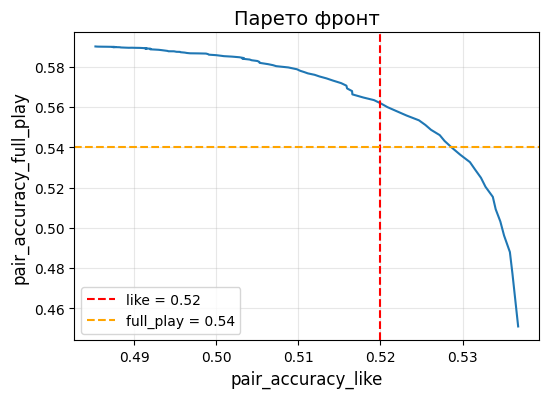

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(like_acc, full_acc)
plt.xlabel('pair_accuracy_like', fontsize=12)
plt.ylabel('pair_accuracy_full_play', fontsize=12)
plt.title('Парето фронт', fontsize=14)
plt.grid(True, alpha=0.3)

plt.axvline(x=0.52, color='red', linestyle='--', label='like = 0.52')
plt.axhline(y=0.54, color='orange', linestyle='--', label='full_play = 0.54')
plt.legend()
plt.show()

Выводы по графику: 

Похоже, моя модель классная, много точек лежат выше ограничений для теста, возможно, это связано с тем, что я добавил много экспертов и кросс слоев. Как видно из логов, модель достигла целевых метрик еще на первой эпохе, но я решил дать ей еще чуть доучиться, видимо, не зря

Получается, что модель сбалансированно умеет предсказывать оба таргета, нет сильного конфликта между задачами

## Подберите итоговый score

Теперь вам нужно подобрать такое значение $\alpha$, при котором итоговый score удовлетворяет ограничениям в тесте.

Напомним, что итоговый score строится как

$$
s = \alpha \cdot P(\text{like}) + (1 - \alpha) \cdot P(\text{full\_play}).
$$

На это можно смотреть как на выбор итогового продуктового компромисса: насколько система готова разменивать качество по лайкам на качество по полным прослушиваниям. В реальной задаче именно такой выбор и приходится делать при построении финального ранжирования.

В этом задании вам нужно:
1. подобрать значение $\alpha$;
2. посчитать итоговый score с этим весом;
3. убедиться, что он проходит ограничения из теста.

In [78]:
import numpy as np


valid_mask = (np.array(like_acc) > 0.52) & (np.array(full_acc) > 0.54)
valid_alphas = np.array(alphas)[valid_mask]
valid_like = np.array(like_acc)[valid_mask]
valid_full = np.array(full_acc)[valid_mask]

total_scores = valid_like + valid_full
best_idx = np.argmax(total_scores)
alpha = float(valid_alphas[best_idx])
combined_score = alpha * like_probs + (1 - alpha) * full_probs

metrics = {
    "pair_accuracy_like": compute_pairwise_accuracy(
        uids=uids,
        timestamps=timestamps,
        labels=labels_like,
        probs=combined_score
    ),
    "pair_accuracy_full_play": compute_pairwise_accuracy(
        uids=uids,
        timestamps=timestamps,
        labels=labels_full,
        probs=combined_score
    ),
}

tests.test_model_multitask_dcnv2_mlp_combined_score_metrics(metrics)

All good! :)


In [83]:
print(f"Итоговые метрики с alpha={alpha:.3f}:")
print(metrics)

Итоговые метрики с alpha=0.790:
{'pair_accuracy_like': 0.520057565471043, 'pair_accuracy_full_play': 0.5617582917162733}
